# Essential Notes

# Settings

### Autoreload of ipynb

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
# os.chdir(r"src")
os.getcwd()

'c:\\Users\\Asus\\Desktop\\UT\\CNRL - Lab\\CNRL-Cortical-Column\\src'


### Changing the path to the main directories path

# Imports

In [3]:
from conex import *
from pymonntorch import *

from matplotlib import pyplot as plt
from PIL import Image

import torchvision
from torch.utils.data import DataLoader

from conex.helpers.filters import DoGFilter

from L423.tools.visualize import *
from L56.RefrenceFrames import RefrenceFrame
from L56.stimuli.current_base import RandomInputCurrent
from L56.synapse.vDistributor import ManualVCoder
from InputLayer.DataLoaderLayer import DataLoaderLayer
from InputLayer.synapse.LocationCoder import LocationCoder
from L423.network.SetTarget import SetTarget
from L423.L423 import L4, L23
from FC import fullyConnected
from FC.synapse.learning import AttentionBasedRSTDP
from FC.tools.model_evaluation import accuracy_score

from L56.tools.visualization import refrence_frame_raster
from L423.tools.visualize import show_filters

from torchvision.datasets import MNIST, FashionMNIST, Caltech101

SyntaxError: invalid syntax (RefrenceFrames.py, line 39)

# Configs

In [4]:
REFRENCE_FRAME_DIM = 23
REFRENCE_INH_DIM = 15
SCREEN_SHOT_PATH = "C:\\Users\\amilion\\Desktop\\develop\\python\\NS\\records\\L5.6"

Input_Width = 80
Input_Height = 80
Crop_Window_Width = 45
Crop_Window_Height = 45
DoG_SIZE = 15

IMAGE_WIDTH = 80
IMAGE_HEIGHT = 80
IMAGE_NUMBER = 100

OUT_CHANNEL = 16
IN_CHANNEL = 1
KERNEL_WIDTH = 35
KERNEL_HEIGHT = 35

DATASET_IMAGE_WIDTH = IMAGE_WIDTH - DoG_SIZE + 1
DATASET_IMAGE_HEIGHT = IMAGE_HEIGHT - DoG_SIZE + 1
INPUT_WIDTH = Crop_Window_Width - DoG_SIZE + 1
INPUT_HEIGHT = Crop_Window_Height - DoG_SIZE + 1

L4_WIDTH = Crop_Window_Width - KERNEL_WIDTH + 1
L4_HEIGHT = Crop_Window_Height - KERNEL_HEIGHT + 1

L23_WIDTH = 1
L23_HEIGHT = 1

J_0 = 200
p = 0.8

N_CLASSES = 2
SACCADE = 3
ITER_PER_SACCADE = 25

TRAIN_IMAGES_NUMBER = 20
TEST_IMAGES_NUMBER = 5
TRAIN_ITERATIONS = TRAIN_IMAGES_NUMBER*N_CLASSES*SACCADE*ITER_PER_SACCADE
REST_INTERVAL = 100
TEST_ITERATIONS = TEST_IMAGES_NUMBER*N_CLASSES*SACCADE*ITER_PER_SACCADE

BATCH_SIZE = 64

DEVICE = "cpu"
DTYPE = torch.float32

# Loading Data

In [5]:
# MNIST_ROOT = "./MNIST"

# dataset_directory_path = "./first_step"

# transformation = torchvision.transforms.Compose([
#     torchvision.transforms.ToTensor(),
#     torchvision.transforms.Grayscale(num_output_channels = 1), # not necessary
#     Conv2dFilter(DoGFilter(size = DoG_SIZE, sigma_1 = 2, sigma_2 = 1, zero_mean=True, one_sum=True).unsqueeze(0).unsqueeze(0)), # type: ignore
#     SqueezeTransform(dim = 0), # type: ignore
# ])


# dataset = MNIST(root=MNIST_ROOT, train=True, download=True, transform=transformation)

# classes = torch.Tensor([])
# for i in range(N_CLASSES) :
#     i_class = dataset.data[dataset.targets == i][:TRAIN_IMAGES_NUMBER + TEST_IMAGES_NUMBER]
#     print(i_class.shape)
#     classes = torch.cat((classes, i_class), dim = 0)

# print(classes.shape)

# target = []
# for i in range(N_CLASSES) :
#     target += [i] * (TRAIN_IMAGES_NUMBER + TEST_IMAGES_NUMBER)
# target = torch.Tensor(target)

# new_dataset_size = classes.shape[0]

# t = torch.arange(new_dataset_size)
# # np.random.shuffle(t.numpy())
# two_class_dataset = classes[t]
# target = target[t]

# new_dataset = torch.empty(0, DATASET_IMAGE_WIDTH, DATASET_IMAGE_WIDTH)
# centers = []

# for i in range(0, new_dataset_size):
#     img = two_class_dataset[i]  # 4 in range [0, 5842) ; 9 in range [5842, 11791)
#     img = transformation(img.numpy())
#     # import pdb;pdb.set_trace()
#     new_dataset = torch.cat((new_dataset.data, img.data.view(1, *img.data.shape)), dim=0)

# new_dataset.to(DEVICE)
# dl = DataLoader(new_dataset, batch_size = BATCH_SIZE,shuffle=False)

In [5]:
import torch

In [6]:
torch.min(torch.tensor([2, 3]))

tensor(2)

In [7]:
class NormalizeTransform(torch.nn.Module):
  def __call__(self, input):
    input = input + torch.abs(torch.min(input))
    _min, _max = torch.min(input), torch.max(input)
    return 5*(input - _min) / ((_max - _min))

In [8]:
MNIST_ROOT = "./Caltech101"

dataset_directory_path = "./first_step"

transformation = torchvision.transforms.Compose([
    torchvision.transforms.Resize((Input_Width, Input_Height)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Grayscale(num_output_channels = 1), # not necessary
    NormalizeTransform(),
    Conv2dFilter(DoGFilter(size = DoG_SIZE, sigma_1 = 10, sigma_2 = 1, zero_mean=True, one_sum=True).unsqueeze(0).unsqueeze(0)), # type: ignore
    SqueezeTransform(dim = 0), # type: ignore
])


dataset = Caltech101(root=MNIST_ROOT, download=True, transform = transformation)

motors = []
faces = []

for data in dataset :
    if(data[1] == 1) :
        faces.append(data[0].view(1, DATASET_IMAGE_WIDTH, DATASET_IMAGE_HEIGHT))

    if(data[1] == 3) :
        motors.append(data[0].view(1, DATASET_IMAGE_WIDTH, DATASET_IMAGE_HEIGHT))


face = torch.cat(faces)
motor = torch.cat(motors)

face_train = face[:TRAIN_IMAGES_NUMBER]
face_test = face[TRAIN_IMAGES_NUMBER:TRAIN_IMAGES_NUMBER + TEST_IMAGES_NUMBER]

motor_train = motor[:TRAIN_IMAGES_NUMBER]
motor_test = motor[TRAIN_IMAGES_NUMBER:TRAIN_IMAGES_NUMBER + TEST_IMAGES_NUMBER]


labels = [0] * TRAIN_IMAGES_NUMBER + [1] * TRAIN_IMAGES_NUMBER + [0] * TEST_IMAGES_NUMBER + [1] * TEST_IMAGES_NUMBER
# labels = [0] * TRAIN_IMAGES_NUMBER + [0] * TEST_IMAGES_NUMBER
labels = torch.tensor(labels)

dataset = torch.cat([face_train, motor_train, face_test, motor_test])
# dataset = torch.cat([face_train, face_test])
dataset.shape

t = torch.arange(len(dataset))
np.random.shuffle(t.numpy())
dataset = dataset[t]
labels = labels[t]

dl = DataLoader(dataset, batch_size = BATCH_SIZE,shuffle=True)

Files already downloaded and verified


In [9]:
from torchvision.transforms.functional import crop

def confidence_crop_interspace(image: torch.Tensor, window_width: int, window_height: int, device="cpu"):
    inp_width = image.size(0)
    inp_height = image.size(1)

    # print(inp_width, inp_height)

    x1 = window_width//2
    x2 = (inp_width - 1) - (window_width//2)
    y1 = window_height//2
    y2 = (inp_height - 1) - (window_height//2)

    """
    5 fixed points on the image to saccade
    """
    cent_x = [window_width//2, window_width//2, inp_width - window_width//2, inp_width - window_width//2, inp_width//2]
    cent_y = [window_height//2, inp_height - window_height//2, window_height//2, inp_height - window_height//2, inp_height//2]

    opt = random.randint(0, 3)
    center_x = cent_x[opt]
    center_y = cent_y[opt]



    # import pdb;pdb.set_trace()

    # center_x = random.randint(x1, x2)
    # center_y = random.randint(y1, y2)
    center_coordinates = [center_x, center_y]
    top_left_x = center_x - (window_width//2)
    top_left_y = center_y - (window_height//2)
    top_left_coordinates = [top_left_x, top_left_y]
    coordinates = torch.tensor([center_coordinates, top_left_coordinates]).to(device)

    # print(center_coordinates)

    return (coordinates, crop(img=image, top=top_left_y, left=top_left_x, height = window_height, width = window_width))

In [10]:
torch.min(dataset[1])

tensor(-1.0961)

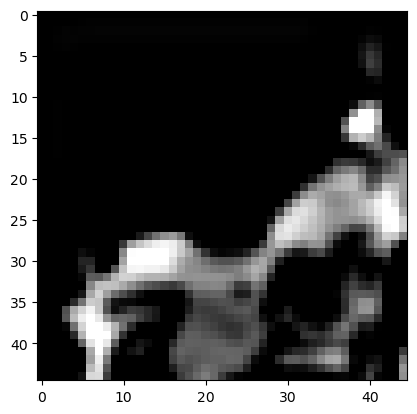

In [11]:
plt.imshow(confidence_crop_interspace(dataset[17], Crop_Window_Width, Crop_Window_Width)[1], cmap = "gray", vmin = 0, vmax = 1)

# Initialize Network

In [12]:
net = Neocortex(
    dt = 1,
    dtype= DTYPE,
    device= DEVICE,
    behavior = {5 : SetTarget(target = labels), 601 : Recorder(["dopamine"], device = DEVICE),},
    index=True
)

## L56

In [13]:
L56 = RefrenceFrame(
    net=net,
    k=N_CLASSES,
    refrence_frame_side=REFRENCE_FRAME_DIM,
    inhibitory_size=REFRENCE_INH_DIM,
    competize=True,
    k_winner_between_all=True,
    lateral_inhibition = False
)

## L4

In [14]:
L4 = L4(
    net = net,
    IN_CHANNEL = IN_CHANNEL,
    OUT_CHANNEL = OUT_CHANNEL,
    HEIGHT = L4_HEIGHT,
    WIDTH = L4_WIDTH,
    INH_SIZE = 13
)

# L23

In [15]:
L23 = L23(
    net = net,
    IN_CHANNEL = IN_CHANNEL,
    OUT_CHANNEL = OUT_CHANNEL,
    HEIGHT = L23_HEIGHT,
    WIDTH = L23_WIDTH
)

## InputLayer

In [16]:
input_layer = DataLoaderLayer(
    net=net,
    data_loader=dl,
    targets=labels,
    widnow_size=Crop_Window_Height,
    saccades_on_each_image=SACCADE,
    rest_interval=10,
    train_iterations=TRAIN_ITERATIONS,
    phase_interval=REST_INTERVAL,
    test_iterations=TEST_ITERATIONS,
    train_images_number=TRAIN_IMAGES_NUMBER * N_CLASSES,
    test_images_number=TEST_IMAGES_NUMBER * N_CLASSES
).build_data_loader()

## FullyConncted

In [17]:
fclayer = fullyConnected.FC(
    net = net,
    N = 10,
    K = N_CLASSES
)

# Synapsis

In [18]:

import torch.nn.functional as F

class MaximumPool2D(BaseDendriticInput):
    """
    Average Pooling on Source population spikes.

    Note: Axon paradigm should be added to the neurons.
          Connection type (Proximal, Distal, Apical) should be specified by the tag
          of the synapse. and Dendrite behavior of the neurons group should access the
          `I` of each synapse to apply them.

    Args:
        current_coef (float): Scalar coefficient that multiplies weights.
    """

    def initialize(self, synapse):
        super().initialize(synapse)
        self.output_shape = (synapse.dst.height, synapse.dst.width)

        if synapse.src.depth != synapse.dst.depth:
            raise RuntimeError(
                f"For pooling, source({synapse.src.depht}) and destionation({synapse.dst.depth}) should have same depth."
            )

    def calculate_input(self, synapse):
        spikes = synapse.pre_spike.view(synapse.src_shape).to(self.def_dtype)
        I = F.adaptive_max_pool2d(spikes, self.output_shape)
        return I.view((-1,))

### Without Learning

In [19]:
class PreSpikeCatcher(Behavior):
    """
    Get the spikes from pre synaptic neuron group and set as src_spike attribute for the synapse group.

    Note: Axon should be added to pre synaptice neuron group
    """
    initialize_last = True

    def initialize(self, synapse):
        synapse.pre_spike = synapse.src.axon.get_spike(synapse.src, synapse.src_delay)

    def forward(self, synapse):
        synapse.pre_spike = synapse.src.axon.get_spike(synapse.src, synapse.src_delay)

In [20]:
Synapsis_L4_L23 = Synapsis(
    net = net,
    src = L4.layer,
    dst = L23.layer,
    input_port="output",
    output_port="input",
    synapsis_behavior=prioritize_behaviors([
        SynapseInit(),
    ]) | ({
        420 : PreSpikeCatcher(),
        185 : AveragePool2D(current_coef = 94 * 500)
    }),
    synaptic_tag="Proximal"
)


Synapsis_Inp_L56 = Synapsis(
    net = net,
    src = input_layer,
    dst = L56.layer,
    input_port = "data_out",
    output_port = "input",
    synapsis_behavior=prioritize_behaviors([
        SynapseInit(),]) | {
        275: LocationCoder()
    },
    synaptic_tag="Proximal"
)

for i in range(0, N_CLASSES):
    Synapsis_FC_L56 = Synapsis(
        net = net,
        src = fclayer.layer,
        dst = L56.layer,
        input_port = f"output_{i}",
        output_port = f"general_input_to_reference{i}",
        synapsis_behavior=prioritize_behaviors([
            SynapseInit(),
            WeightInitializer(mode = "normal(5, 0)"),
            SimpleDendriticInput(current_coef = 1),
        ]),
        synaptic_tag="Apical"
)


In [21]:
class WeightDecay(Behavior) :

  def forward(self, synapse) :

    if(synapse.network.iteration % 100 != 0) :
      return

    synapse.weights += (-synapse.weights) / 99

In [22]:
prioritize_behaviors([Fire()])

{340: Fire()}

### With Learning

In [23]:
Synapsis_Inp_L4 = Synapsis(
    net = net,
    src = input_layer,
    dst = L4.layer,
    input_port="data_out",
    output_port="input",
    synapsis_behavior=prioritize_behaviors([
        SynapseInit(),
        WeightInitializer(weights = torch.normal(0.1, 0.6, (OUT_CHANNEL, IN_CHANNEL, KERNEL_HEIGHT, KERNEL_WIDTH)).to(DEVICE) ),
        Conv2dDendriticInput(current_coef = 2 , stride = 1, padding = 0),
        Conv2dSTDP(a_plus=15, a_minus=1),
        WeightNormalization(norm = KERNEL_WIDTH * KERNEL_WIDTH // 5),
        WeightClip(w_min = 0, w_max = 1)
    ]),
    synaptic_tag="Proximal"
)

Synapsis_L23_FC = Synapsis(
    net = net,
    src = L23.layer,
    dst = fclayer.layer,
    input_port="output",
    output_port="input",
    synapsis_behavior=prioritize_behaviors([
        SynapseInit(),
        WeightInitializer(mode = "normal(0.1, 4)"),
        SimpleDendriticInput(current_coef = 100),
        # WeightNormalization(norm = 30),
        WeightClip(w_min = 0, w_max = 5)
    ]) | ({
        400 : AttentionBasedRSTDP(a_plus = 0.01 , a_minus = 0.005, tau_c = 6, attention_plus = 1, attention_minus = -0.5, number_of_classes = N_CLASSES),
    }),
    synaptic_tag="Proximal"
)

L23_to_L56 = Synapsis(
    net=net,
    src=L23.layer,
    dst=L56.layer,
    input_port="output",
    output_port="input",
    synaptic_tag="Apical, exi",
    synapsis_behavior=prioritize_behaviors(
        [
            SynapseInit(),
            SimpleDendriticInput(),
            WeightInitializer(mode="normal(0.1, 0)"),
            # SimpleSTDP(w_min=0, w_max=0.9, a_plus=0.0003, a_minus=0),
            # WeightNormalization(norm=)
            WeightClip(w_min = 0, w_max = 2)
        ]
    )| ({
        400 : AttentionBasedRSTDP(a_plus = 0.0003 , a_minus = 0.0001, tau_c = 6, attention_plus = 1, attention_minus = 0, number_of_classes = N_CLASSES),
    }),
)

L56_to_L23 = Synapsis(
    net=net,
    src=L56.layer,
    dst=L23.layer,
    input_port="output",
    output_port="input",
    synaptic_tag="Apical, exi",
    synapsis_behavior=prioritize_behaviors(
        [
            SynapseInit(),
            SimpleDendriticInput(),
            WeightInitializer(mode="normal(0.05, 0.01)"),
            # SimpleSTDP(w_min=0, w_max=10, a_plus=0.005, a_minus=0.0008)
            SimpleRSTDP(a_plus=0.0003, a_minus=0.0001, tau_c=6, w_min=0, w_max=1)
        ]
    )| ({
        # 400 : AttentionBasedRSTDP(a_plus = 0.0003 , a_minus = 0.001, tau_c = 6, attention_plus = 1, attention_minus = 0, number_of_classes = N_CLASSES),
    }),
)

# Simulate Network

In [24]:
s = L4.layer.sub_structures[0].vector()
sizes = 0
for sub in L4.layer.sub_structures:
  if ("syn" in sub.tags):
    sizes += sub.src.size*sub.dst.size

print(sizes/1024**3)

0.0034906864166259766


In [25]:
net.initialize()

Network['Neocortex'](Neurons: tensor(5558)|11 groups, Synapses: tensor(10476545)|29 groups){1:TimeResolution(dt=1,)5:SetTarget(target=tensor([0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
        1, 1]),)100:ConfidenceLevelPayOff(initial_payoff=0.0,punish=-0.8,reward=0.8,offset=500,)120:Dopamine(tau_dopamine=6,initial_dopamine_concentration=None,)601:Recorder(variables=None,gap_width=0,max_length=None,auto_annotate=True,tag=None,device=cpu,arg_0=['dopamine'],)}
NeuronGroup['RefrenceFrame', '0', 'NeuronGroup', 'ng'](529){0:NeuronDimension(depth=1,height=23,width=23,input_patterns=None,)220:SimpleDendriteStructure(Proximal_max_delay=1,Distal_max_delay=1,Apical_max_delay=None,proximal_min_delay=0,distal_min_delay=0,apical_min_delay=None,)240:SimpleDendriteComputation(I_tau=None,apical_provocativeness=0.99,distal_provocativeness=None,)250:ConstantCurrent(scale=1.7,)260:GPCell(R=8,tau=5

In [26]:
entities = 0
for syn in net.SynapseGroups :
    print((syn.src.size, syn.dst.size))
    try :
        print(syn.weights.shape)
    except :
        pass
    entities += syn.src.size * syn.dst.size

print("all syn : ", entities)
print("entities in GB : ", entities * 4 / (2**30))

(15, 529)
torch.Size([15, 529])
(529, 15)
torch.Size([529, 15])
(529, 529)
torch.Size([529, 529])
(15, 529)
torch.Size([15, 529])
(529, 15)
torch.Size([529, 15])
(529, 529)
torch.Size([529, 529])
(15, 15)
torch.Size([15, 15])
(1936, 1936)
torch.Size([1, 1, 33, 13, 13])
(16, 4)
torch.Size([16, 4])
(4, 16)
torch.Size([4, 16])
(4, 4)
torch.Size([4, 4])
(8, 8)
torch.Size([8, 8])
(4, 8)
torch.Size([4, 8])
(8, 4)
torch.Size([8, 4])
(8, 8)
torch.Size([8, 8])
(4, 8)
torch.Size([4, 8])
(8, 4)
torch.Size([8, 4])
(1936, 16)
(2025, 529)
(2025, 529)
(8, 529)
torch.Size([8, 529])
(8, 529)
torch.Size([8, 529])
(2025, 1936)
torch.Size([16, 1, 35, 35])
(16, 8)
torch.Size([16, 8])
(16, 8)
torch.Size([16, 8])
(16, 529)
torch.Size([16, 529])
(16, 529)
torch.Size([16, 529])
(529, 16)
torch.Size([529, 16])
(529, 16)
torch.Size([529, 16])
all syn :  10476545
entities in GB :  0.03902817144989967


In [27]:
net.simulate_iterations(TRAIN_ITERATIONS)

3000xBatch: 1/1 (100%) 196529.633ms


196529.63256835938

# Visualization

## Filters

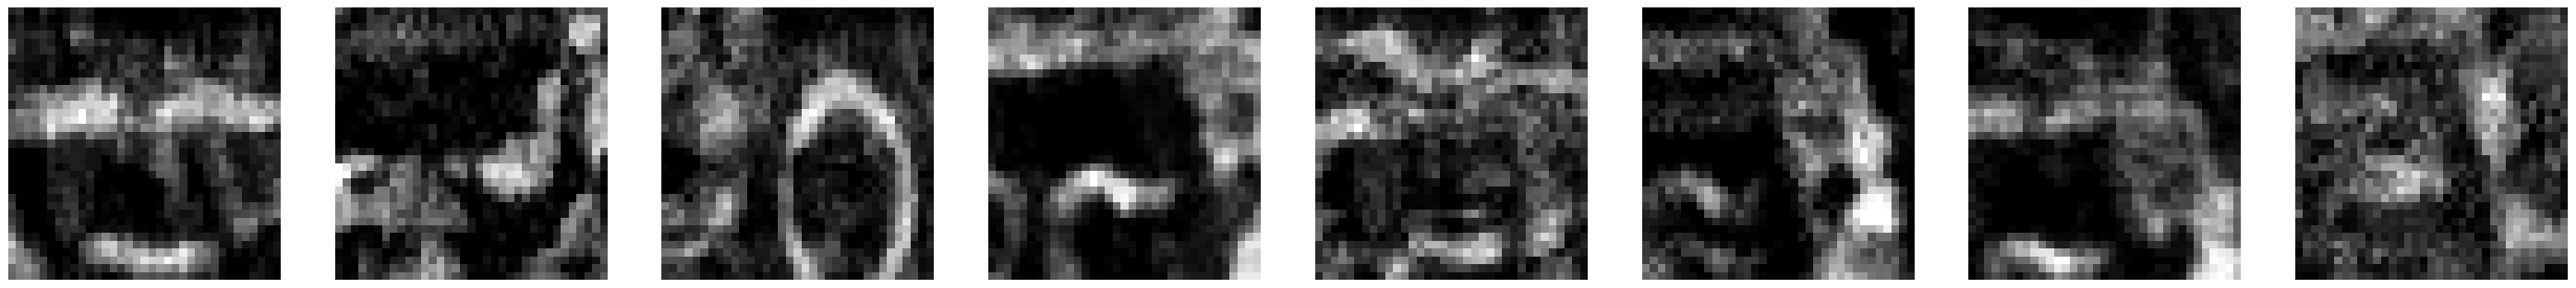

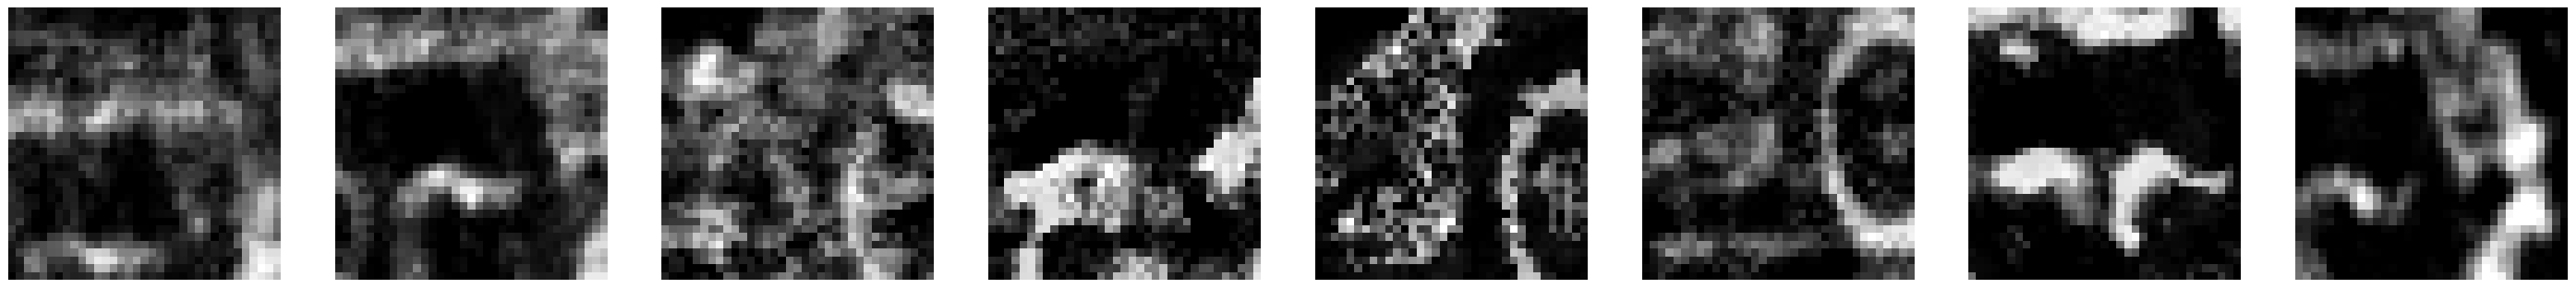

In [28]:
for i in range(2) :
    show_filters(torch.Tensor.cpu(Synapsis_Inp_L4.synapses[0].weights[i*8:(i+1)*8]))

In [29]:
Synapsis_Inp_L4.synapses[0].weights.shape

torch.Size([16, 1, 35, 35])

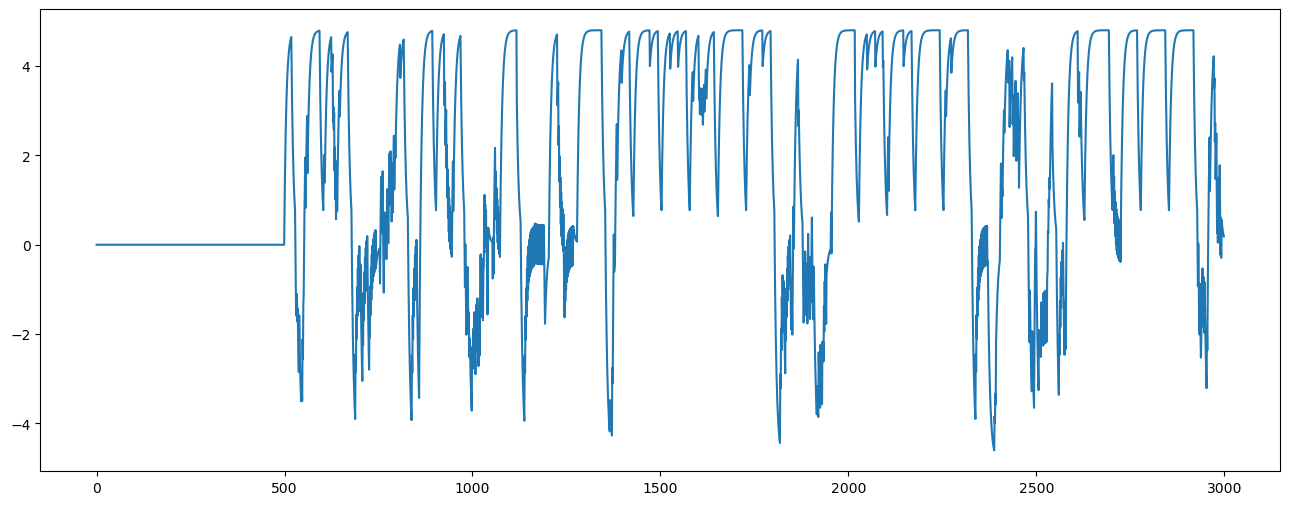

In [30]:

plt.figure(figsize=(16, 6))
plt.plot(torch.Tensor.cpu(net["dopamine", 0]))
plt.show()

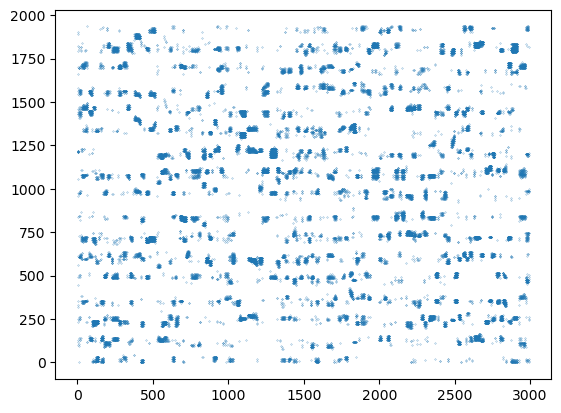

In [31]:
plt.plot(torch.Tensor.cpu(L4.ng_e["spikes.t", 0]), torch.Tensor.cpu(L4.ng_e["spikes.i", 0]), 'o', markersize = 0.2)
# plt.xlim(1680, 1860)
plt.show()

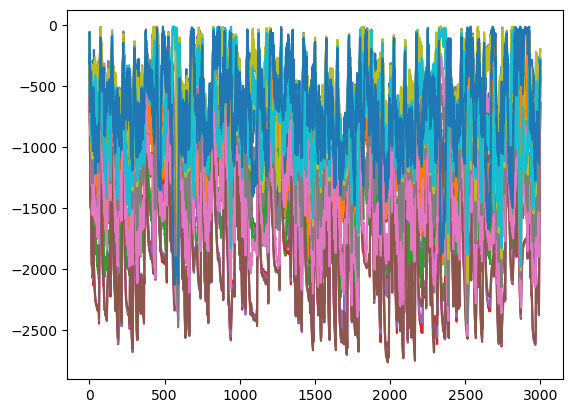

In [32]:
plt.plot(torch.Tensor.cpu(L4.ng_e["v", 0][:,(21*21) * 2:(21*21) * 2 + 21]))

In [33]:
torch.max(Synapsis_Inp_L4.synapses[0].weights), torch.min(Synapsis_Inp_L4.synapses[0].weights)

(tensor(1.), tensor(0.))

In [34]:
def raster_L23(layer, start_itr, end_itr):
  times = torch.Tensor.cpu(layer.ng_e["spikes.t", 0])
  spikes = torch.Tensor.cpu(layer.ng_e["spikes.i", 0])
  mask = torch.Tensor.cpu((start_itr<=times)&(times<=end_itr))
  plt.scatter(times[mask], spikes[mask])
  plt.ylim(0, OUT_CHANNEL)
  plt.show()

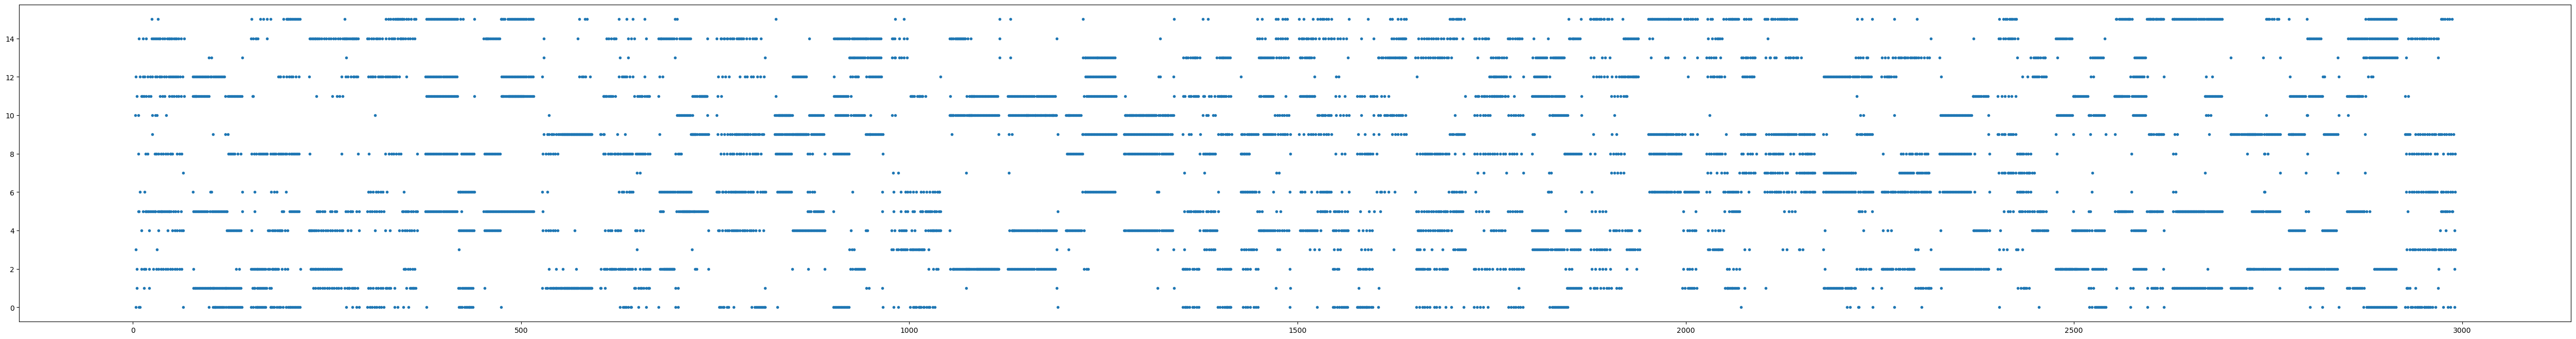

In [35]:
plt.figure(figsize=(64, 8))
plt.plot(torch.Tensor.cpu(L23.ng_e["spikes.t", 0]), torch.Tensor.cpu(L23.ng_e["spikes.i", 0]), '.')
# plt.xlim(1350, 1425)
plt.show()

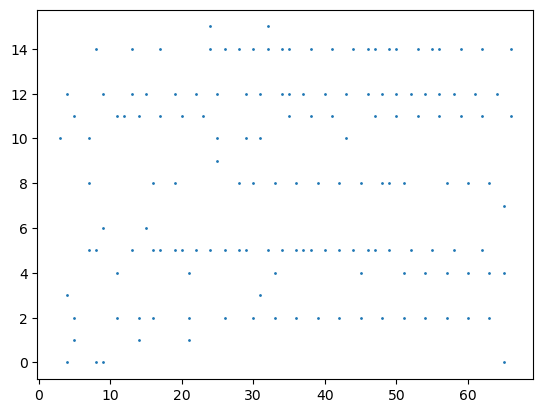

In [36]:
plt.plot(torch.Tensor.cpu(L23.ng_e["spikes.t", 0][L23.ng_e["spikes.t", 0] <= 70]), torch.Tensor.cpu(L23.ng_e["spikes.i", 0][L23.ng_e["spikes.t", 0] <= 70]), "o", markersize = 1)
plt.show()

# Rest Interval

In [37]:
net.simulate_iterations(REST_INTERVAL)

100xBatch: 1/1 (100%) 7504.168ms


7504.167556762695

# Test Section

### Clearing learnings

In [38]:
Synapsis_Inp_L4.remove_behavior(400)
Synapsis_L23_FC.remove_behavior(400)
# L23_to_L56.remove_behavior(400)
# L56_to_L23.remove_behavior(400)

### Running Network

In [39]:
net.simulate_iterations(TEST_ITERATIONS)
# net["targets"]

750xBatch: 1/1 (100%) 53420.741ms


53420.740604400635

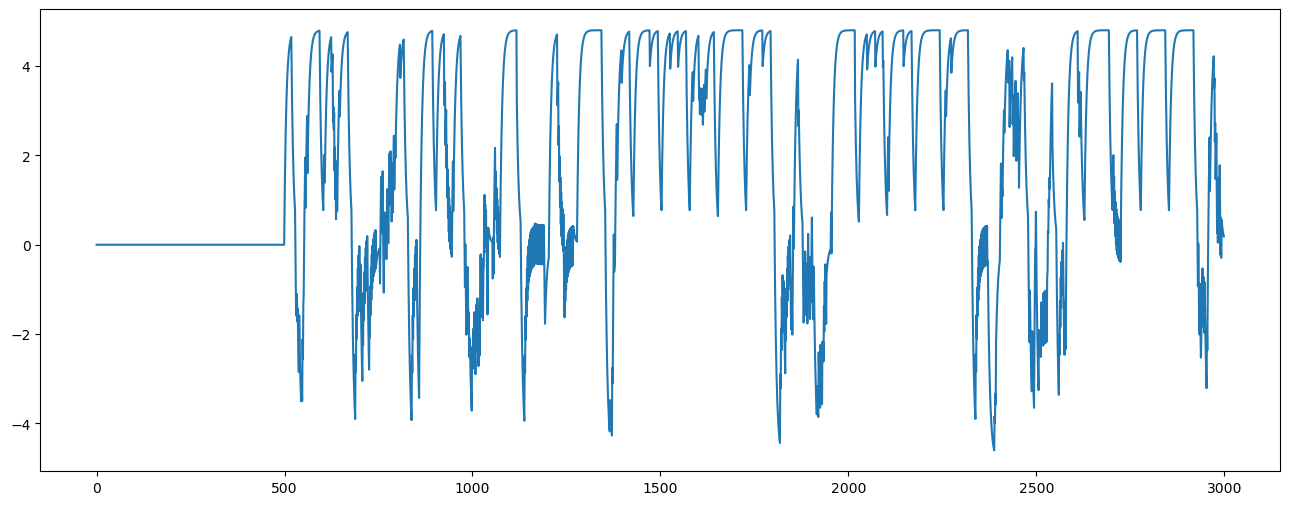

In [40]:
plt.figure(figsize=(16, 6))
plt.plot(torch.Tensor.cpu(net["dopamine", 0]))
plt.show()

## Accuracy Score

In [41]:
# print("Test Accuracy :", accuracy_score(
#     fclayer.E_NG_GROUP,
#     K = N_CLASSES,
#     window_size = TEST_ITERATIONS // (TEST_IMAGES_NUMBER * N_CLASSES),
#     targets=labels[TRAIN_IMAGES_NUMBER * N_CLASSES:],
#     dataset_size = TEST_IMAGES_NUMBER * N_CLASSES,
#     offset=TRAIN_ITERATIONS + REST_INTERVAL) * 100
# )

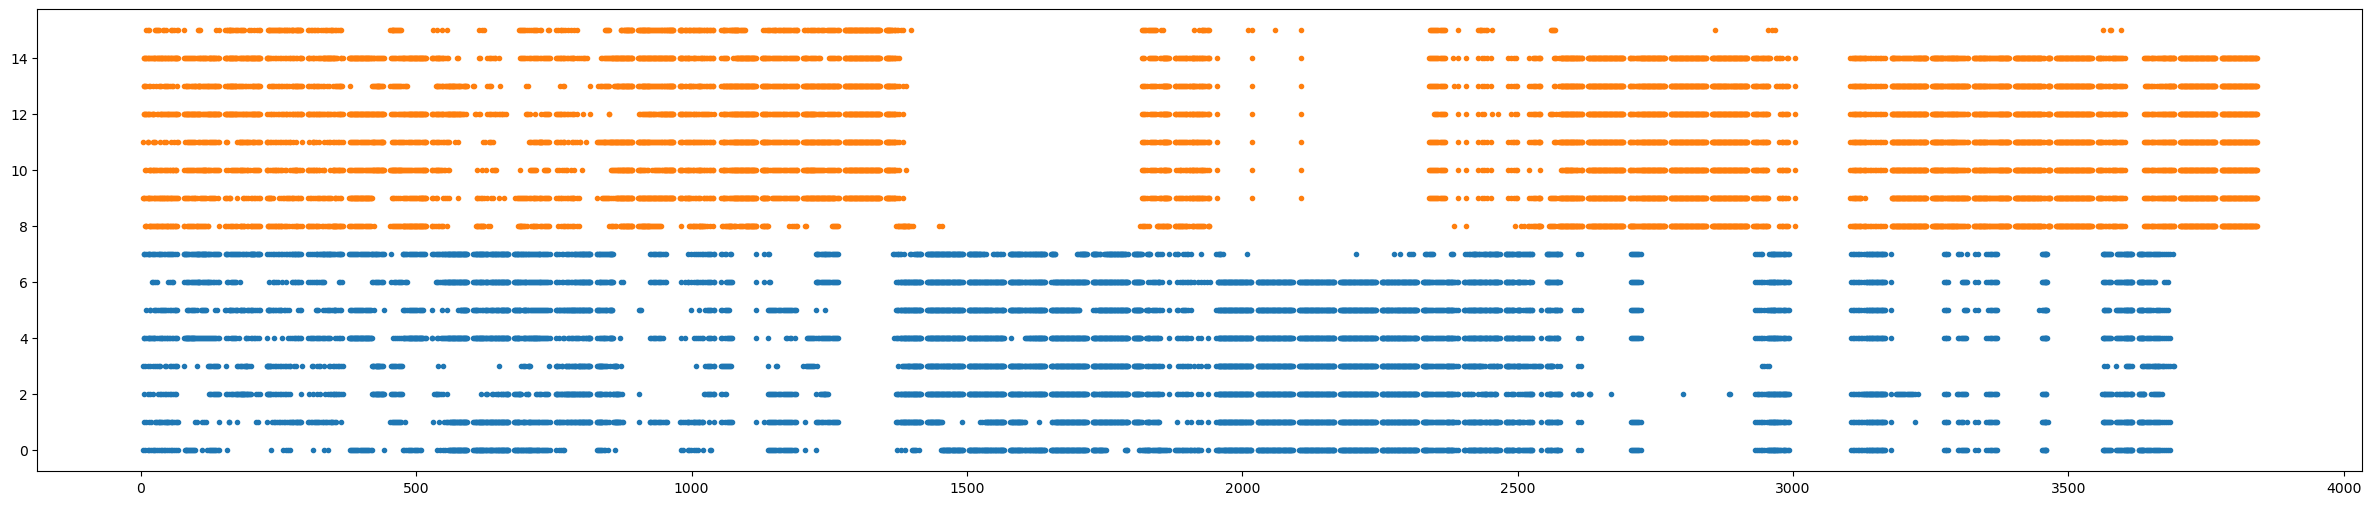

In [42]:
plt.figure(figsize=(30, 6))

# plt.xlim((1200, 1230))
for i in range(N_CLASSES) :
  plt.plot(fclayer.E_NG_list[i]['spikes.t', 0], fclayer.E_NG_list[i]['spikes.i', 0] + 8*i, '.')

In [43]:
plt.plot(torch.sum(spikes, dim = 1))
# plt.xlim(700, 750)
plt.show()

NameError: name 'spikes' is not defined

In [ ]:
plt.plot(torch.sum(spikes, dim = 1))
# plt.xlim(700, 750)
plt.show()

NameError: name 'spikes' is not defined

In [44]:
num = 5
start_itr, end_itr  = num*60, num*60 + 30
# start_itr, end_itr  = num*60 + 45, num*60 + 75

# Decision-Making Raster Plot

In [46]:

# plt.figure(figsize=(30, 6))
# # for i in range(fclayer.K) :
#     # a = (i * 1600)
#     # b = ((i + 1) * 1600)

# times = torch.logical_and(fclayer.E_NG_GROUP['spikes.t', 0] < end_itr, start_itr <= fclayer.E_NG_GROUP['spikes.t', 0])

# for i in range(N_CLASSES) :
#   plt.xlim((start_itr, end_itr))
#   plt.plot(torch.Tensor.cpu(fclayer.E_NG_GROUP['spikes.t', 0][times]), torch.Tensor.cpu(fclayer.E_NG_GROUP['spikes.i', 0][times]), '.')
  # plt.plot(torch.Tensor.cpu(fclayer.E_NG_GROUP['spikes.t', 0][torch.logical_and(fclayer.E_NG_GROUP['spikes', 0][:,1] >= i*8, fclayer.E_NG_GROUP['spikes', 0][:,1] < (i+1)*8)]), torch.Tensor.cpu(fclayer.E_NG_GROUP['spikes.i', 0][torch.logical_and(fclayer.E_NG_GROUP['spikes', 0][:,1] >= i*8, fclayer.E_NG_GROUP['spikes', 0][:,1] < (i+1)*8)]), '.')

## Refrence Frames Visualize

In [45]:
def raster_refrence_frames(layer, refrence_num = 3, start_itr = 0, end_itr = 30):
  frames = []
  for ng in layer.neuron_groups:
    if "RefrenceFrame" in ng.tags:
      frames.append(ng)
  ng = frames[refrence_num - 1]
  spikes = ng["spikes"][0]
  fig, axes = plt.subplots(5, (end_itr - start_itr) // 5, figsize = (10, 10))
  idx = start_itr
  for row in range(5):
    for col in range((end_itr - start_itr) // 5):
      poses = spikes[idx].nonzero(as_tuple = False)
      _x = poses // ng.height
      _y = poses % ng.width
      axes[row][col].scatter(_x, _y)
      axes[row][col].set_title(f"itr {idx}")
      axes[row][col].set_xlim(0, REFRENCE_FRAME_DIM)
      axes[row][col].set_ylim(0, REFRENCE_FRAME_DIM)
      idx += 1
  plt.tight_layout()
  plt.show()

In [46]:
def raster_input_frames(layer, refrence_num = 3, start_itr = 0, end_itr = 30):
  frames = []
  for ng in layer.neuron_groups:
    if "InputRefrenceFrame" in ng.tags:
      frames.append(ng)

  for i in range(N_CLASSES) :
    plt.plot(frames[i]['spikes.t', 0], frames[i]['spikes.i', 0] + i*1, '.')
  plt.tight_layout()
  plt.show()

In [47]:
def v_refrence_frames(layer, refrence_num = 3, start_itr = 0, end_itr = 30):
  frames = []
  for ng in layer.neuron_groups:
    if "RefrenceFrame" in ng.tags:
      frames.append(ng)
  ng = frames[refrence_num - 1]
  # plt.xlim((2190, 2200))
  # plt.ylim((-10000, 0))
  plt.plot(ng["v", 0])
  plt.show()

In [48]:
def v_input_frames(layer, refrence_num = 3, start_itr = 0, end_itr = 30):
  frames = []
  for ng in layer.neuron_groups:
    if "InputRefrenceFrame" in ng.tags:
      frames.append(ng)
  ng = frames[refrence_num - 1]
  print(ng["spikes", 0])
  plt.plot(ng["v", 0])
  plt.show()

In [49]:
# raster_input_frames(L56, refrence_num=1, start_itr = start_itr, end_itr= end_itr)

In [50]:
# v_input_frames(L56, refrence_num=2, start_itr = start_itr, end_itr= end_itr)

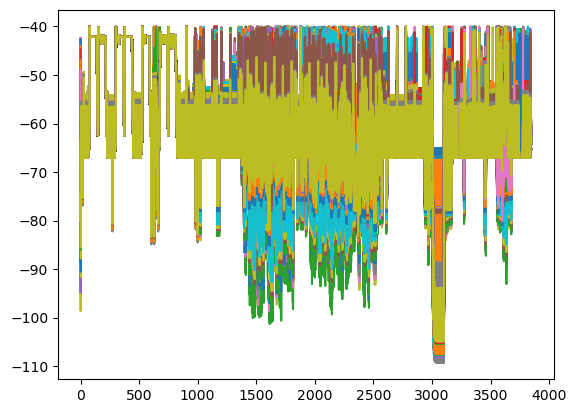

In [51]:
v_refrence_frames(L56, refrence_num=2, start_itr = start_itr, end_itr= end_itr)

In [52]:
print(torch.bincount(fclayer.layer.neurongroups[1]["spikes", 0][:, 0]).tolist()[5:10])

[4, 4, 0, 5, 6]


In [53]:
print(torch.bincount(fclayer.layer.neurongroups[1]["spikes", 0][:, 0]).tolist()[1200:1220])

[0, 0, 0, 6, 7, 6, 6, 6, 7, 5, 7, 5, 7, 5, 7, 5, 7, 5, 7, 5]


In [54]:
print(torch.bincount(fclayer.layer.neurongroups[0]["spikes", 0][:, 0]).tolist()[1200:1220])

[0, 0, 0, 1, 0, 1, 1, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2]


In [55]:
frames = []
for ng in L56.neuron_groups:
    if "RefrenceFrame" in ng.tags:
        frames.append(ng)
ng = frames[0]
spikes = ng["spikes"][0]
# print(spikes.shape)
print(torch.sum(spikes, dim=1).tolist()[1800:1820])

[0, 0, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22]


In [56]:
frames = []
for ng in L56.neuron_groups:
    if "RefrenceFrame" in ng.tags:
        frames.append(ng)
ng = frames[1]
spikes = ng["spikes"][0]
# print(spikes.shape)
print(torch.sum(spikes, dim=1).tolist()[1800:1820])

[0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]


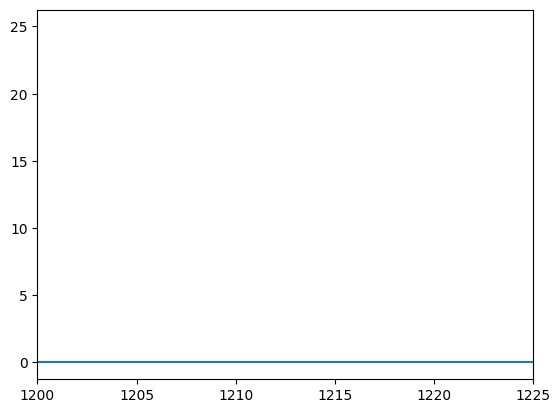

In [72]:
plt.plot(torch.sum(spikes, dim = 1))
plt.xlim(1200, 1225)
plt.show()

In [57]:
frames = []
for ng in L56.neuron_groups:
    if "RefrenceFrame" in ng.tags:
        frames.append(ng)
ng = frames[1]
_v = ng["_v"][0]
# print(_v.shape)
print(_v.tolist()[1820:1830])

[[22.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]


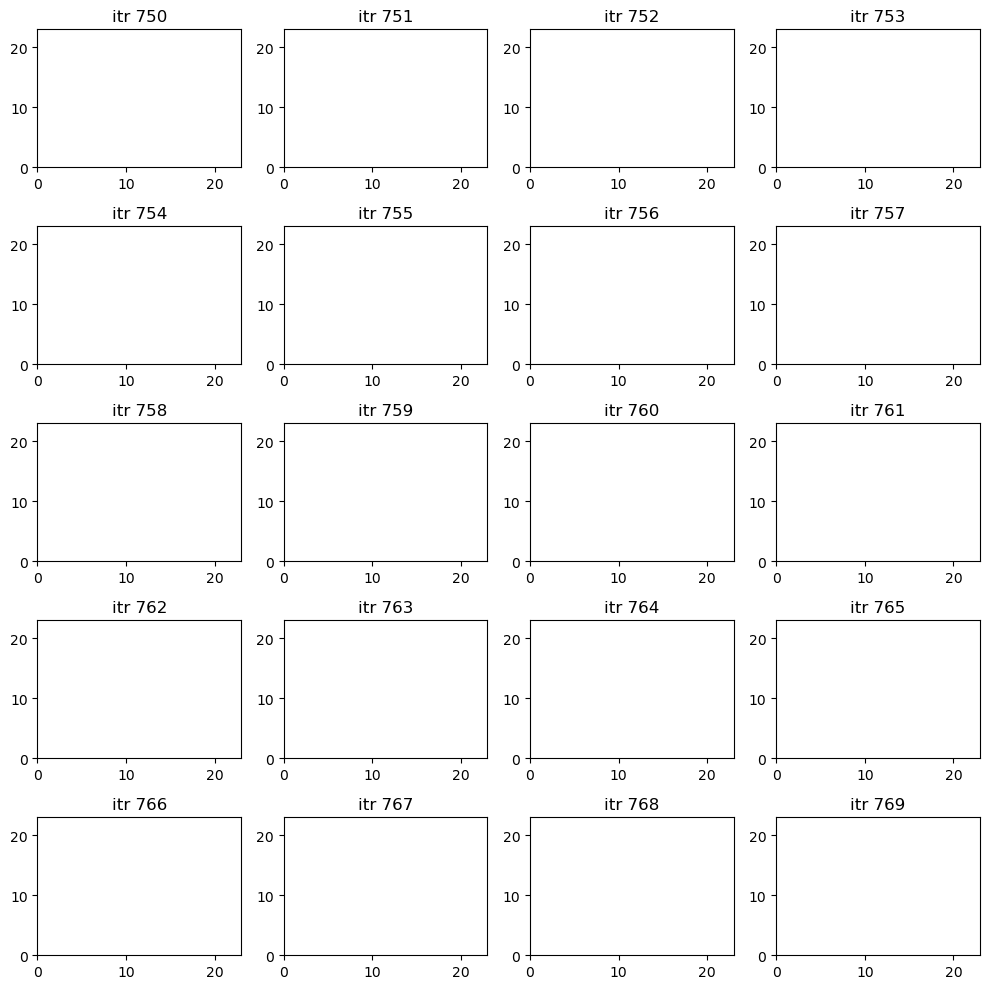

In [77]:
raster_refrence_frames(L56, refrence_num=2, start_itr = 750, end_itr= 770)

### Face and Motor sepration test

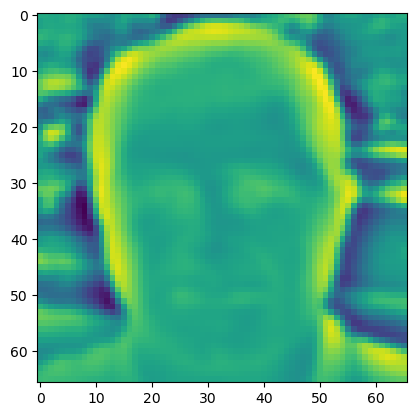

In [59]:
face, motor = dataset[TRAIN_IMAGES_NUMBER*2], dataset[TRAIN_IMAGES_NUMBER*2 + TEST_IMAGES_NUMBER]
plt.imshow(face)
plt.show()

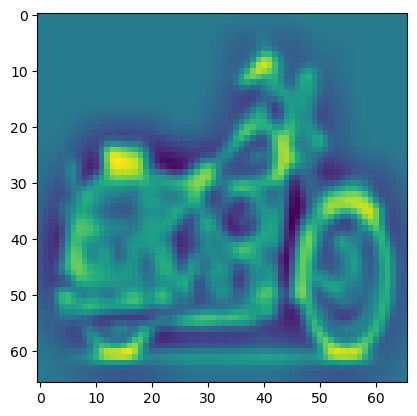

In [60]:
plt.imshow(motor)
plt.show()

In [61]:
face_itr_start, motor_itr_start = (TRAIN_IMAGES_NUMBER*2)*60 + 100 , (TRAIN_IMAGES_NUMBER * 2 + TEST_IMAGES_NUMBER)*60 + 100
face_itr_start, motor_itr_start

(2500, 2800)

In [62]:
shift = 100

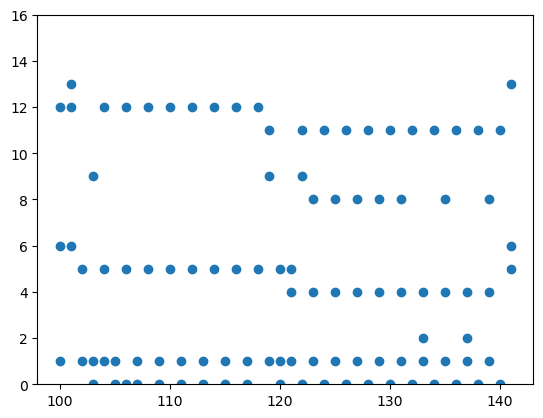

In [63]:
raster_L23(L23, shift, shift+50)

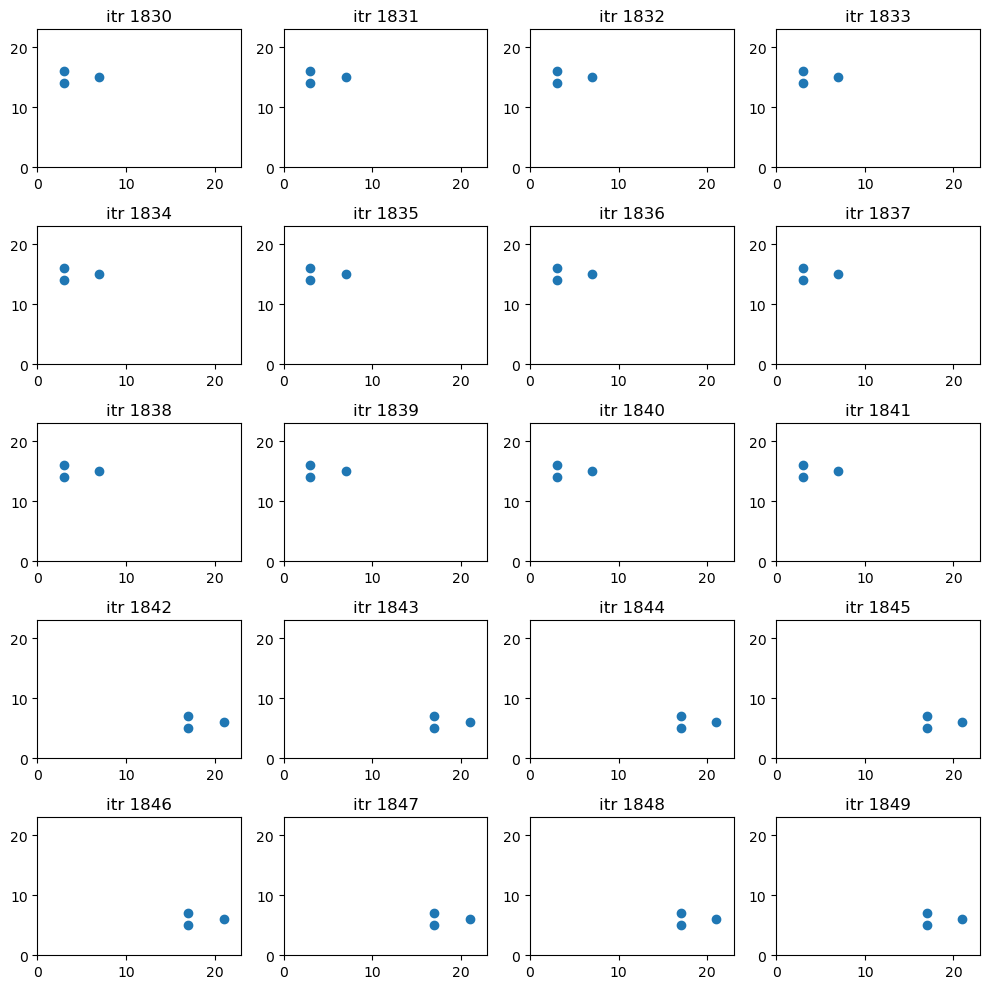

In [64]:
raster_refrence_frames(L56, refrence_num=2, start_itr = 1830, end_itr= 1800 + 50)

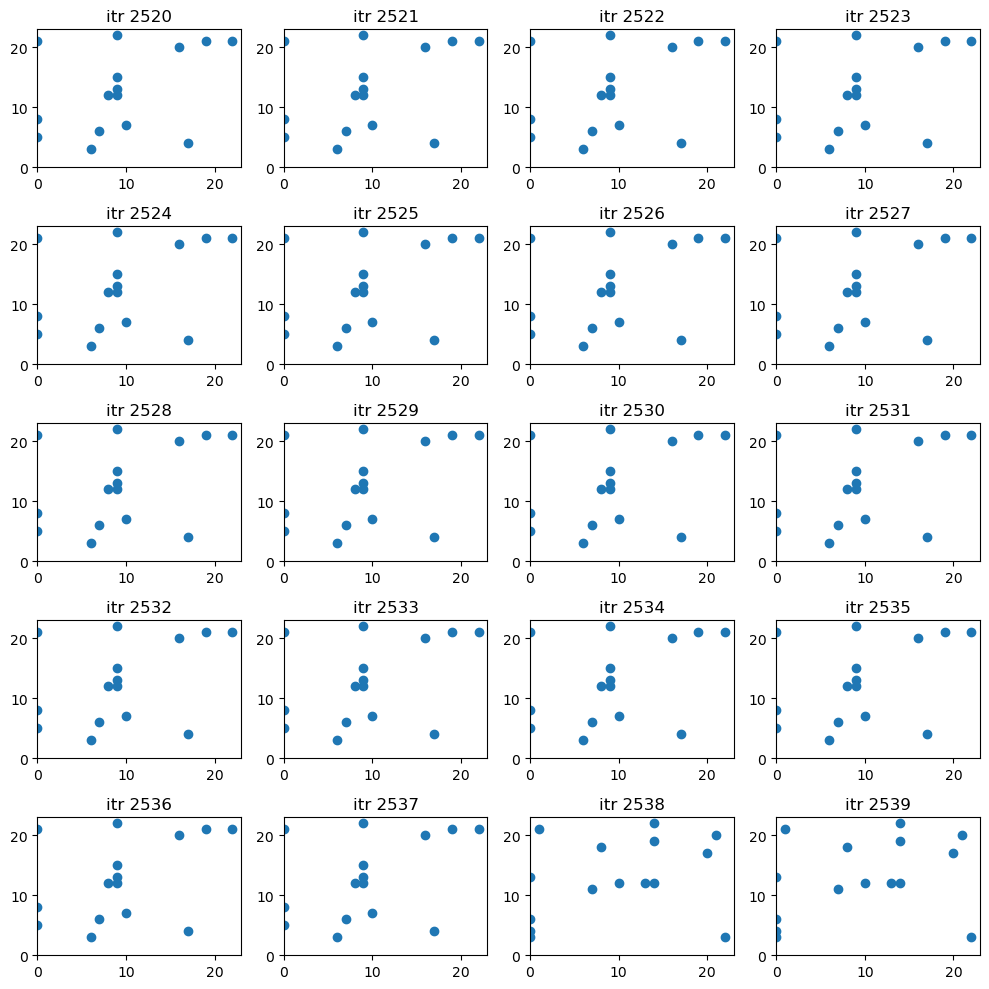

In [65]:
raster_refrence_frames(L56, refrence_num=1, start_itr = face_itr_start+20, end_itr= face_itr_start + 40)

# Accuracy List

In [ ]:
from FC.tools.model_evaluation import model_prediction

Y_hat = []
for i in range(TEST_IMAGES_NUMBER * N_CLASSES) :
  y = labels[TRAIN_IMAGES_NUMBER*N_CLASSES + i]
  y_hat = model_prediction(
      fc_ng = fclayer.E_NG_GROUP,
      K = N_CLASSES,
      st_iter = i * (TEST_ITERATIONS // (TEST_IMAGES_NUMBER * N_CLASSES)),
      en_iter = (i + 1) * (TEST_ITERATIONS // (TEST_IMAGES_NUMBER * N_CLASSES)),
      offset = TRAIN_ITERATIONS + REST_INTERVAL
  )

  Y_hat.append(y_hat)

  if(y != y_hat) :
    print(f"prediction {y_hat}, result : {y}")

AttributeError: 'FC' object has no attribute 'E_NG_GROUP'

In [ ]:
torch.min(Synapsis_L23_FC.synapses[0].weights)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(target[TRAIN_IMAGES_NUMBER*N_CLASSES:], Y_hat, labels = [i for i in range(N_CLASSES)])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = [i for i in range(N_CLASSES)])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)

NameError: name 'target' is not defined

In [ ]:
import torch

# Check memory before creating tensors
print("Initial memory allocated:", torch.cuda.memory_allocated())
print("Initial memory reserved:", torch.cuda.memory_reserved())

# Create a tensor and move it to the GPU
tensor = torch.rand((1024, 1024), device='cuda')
print("Memory allocated after tensor creation:", torch.cuda.memory_allocated())
print("Memory reserved after tensor creation:", torch.cuda.memory_reserved())

# Clear the tensor and free memory
del tensor
torch.cuda.empty_cache()  # Important for manually clearing cached memory
print("Memory after deletion:", torch.cuda.memory_allocated())

In [ ]:
# Run some operation to measure peak memory
print("Peak memory allocated during operation:", torch.cuda.max_memory_allocated())